In [49]:
import pandas as pd
import numpy as np
import os

# Load dataset
file_path = 'data/bitcoin_sentiments_21_24.csv'  # Update with your file path
df = pd.read_csv(file_path, parse_dates=['Date'])

# Define sentiment classification
threshold_positive = 0.5
threshold_negative = -0.5
def classify_sentiment(score):
    if score >= threshold_positive:
        return 'Positive'
    elif score <= threshold_negative:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Accurate Sentiments'].apply(classify_sentiment)

# Aggregate sentiment counts per day
df['Date'] = df['Date'].dt.date  # Convert to date only (remove time)
sentiment_summary = df.groupby('Date')['Sentiment'].value_counts().unstack(fill_value=0)

# Ensure output directory exists
output_dir = 'data'
os.makedirs(output_dir, exist_ok=True)

# Save output
output_dir = os.path.expanduser("~/Desktop")
output_file = os.path.join(output_dir, "etl_sentiment_per_day.csv")
sentiment_summary.to_csv(output_file)


# Display results
sentiment_summary.head()


Sentiment,Negative,Neutral,Positive
Date,,,
2021-11-05,0,3,2
2021-11-06,0,1,0
2021-11-08,1,3,0
2021-11-09,0,3,1
2021-11-10,2,1,1


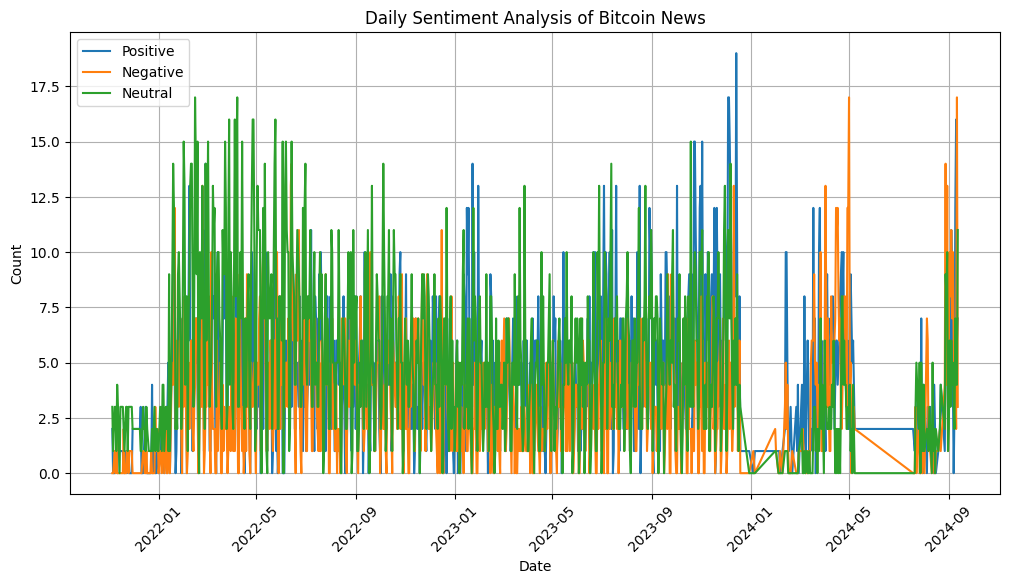

In [53]:
import matplotlib.pyplot as plt

# Plot sentiment trends
def plot_sentiment_trends(df):
    plt.figure(figsize=(12, 6))
    for sentiment in ['Positive', 'Negative', 'Neutral']:
        if sentiment in df.columns:
            plt.plot(df.index, df[sentiment], label=sentiment)
    
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.title('Daily Sentiment Analysis of Bitcoin News')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

plot_sentiment_trends(sentiment_summary)